# Inference & Results
This notebook loads the fine-tuned RoBERTa classifier, runs inference on the test split from the project dataloader, computes evaluation metrics, and produces result plots suitable for the README results section.

In [5]:
from pathlib import Path
import sys, importlib, inspect, shutil
import json
import torch
import numpy as np
import matplotlib.pyplot as plt

# determine project root (notebook may be in notebooks/)
project_root = Path.cwd()
if not (project_root / 'src').exists():
    project_root = project_root.parent
src_root = project_root / 'src'
print('cwd:', Path.cwd())
print('project_root:', project_root)
print('src exists:', src_root.exists())
# ensure src is importable
if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))
print('sys.path[0]:', sys.path[0])
# clear import caches and remove any previously loaded local package
importlib.invalidate_caches()
if 'models' in sys.modules:
    del sys.modules['models']
shutil.rmtree(str(src_root / 'models' / '__pycache__'), ignore_errors=True)
# import the local models package (lazy loader)
try:
    import models
    print('models package loaded from', inspect.getsourcefile(models))
except Exception:
    import traceback; traceback.print_exc()

from data.dataloader import get_data_loaders

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

cwd: /gpfs/home/jacklitt/Deep_learning_final/notebooks
project_root: /gpfs/home/jacklitt/Deep_learning_final
src exists: True
sys.path[0]: /usr/lib64/python311.zip
models package loaded from /gpfs/home/jacklitt/Deep_learning_final/src/models/__init__.py
Device: cpu


In [6]:
# load tokenizer + model using the package helper
save_dir = project_root / 'outputs' / 'roberta_trump'
model_name = 'roberta-base'

try:
    model, tokenizer, device = models.load_model(save_dir, model_name=model_name, device=device)
    print('Loaded model via models.load_model from', save_dir)
    metrics_path = save_dir / 'metrics.json'
    if metrics_path.exists():
        with metrics_path.open('r', encoding='utf-8') as handle:
            saved_metrics = json.load(handle)
        print('Saved training metrics:', saved_metrics)
    else:
        print('No metrics.json found at', metrics_path)
except Exception as exc:
    import traceback; traceback.print_exc()
    raise RuntimeError('Failed to load the trained classifier checkpoint; stop here instead of evaluating a stale model.') from exc

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 13388.82it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded model via models.load_model from /gpfs/home/jacklitt/Deep_learning_final/outputs/roberta_trump
Saved training metrics: {'train_loss': 0.507732448059243, 'train_accuracy': 0.7251082251082251, 'dev_loss': 0.30505686663722587, 'dev_accuracy': 0.9152542372881356, 'test_loss': 0.16218049384718924, 'test_accuracy': 0.9298245614035088, 'model_name': 'roberta-base', 'max_length': 256, 'batch_size': 8, 'epochs': 4}


In [7]:
# Load the dataloaders (test split)
train_loader, test_loader, dev_loader = get_data_loaders(
    base_path=project_root / 'src' / 'data' / 'us2020data' / 'data_clean',
    file_format='jsonl',
    text_column='CleanText',
    label_column='POTUS',
    candidates=['Joe Biden', 'Donald Trump'],
    split_ratios=(0.8, 0.1, 0.1),
    batch_size=16,
    num_workers=0,
    seed=42,
    shuffle_train=False,
)

print('Test batches:', len(test_loader))

Test batches: 4


In [8]:
# Run inference on the test split and collect predictions
all_labels = []
all_preds = []
all_probs = []

def tokenize_batch(texts):
    return tokenizer(list(texts), padding=True, truncation=True, max_length=256, return_tensors='pt')

for batch in test_loader:
    texts, labels = batch
    encoded = tokenize_batch(texts)
    input_ids = encoded['input_ids'].to(device)
    attention_mask = encoded['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=-1)[:, 1].cpu().numpy()  # probability for positive class
        preds = logits.argmax(dim=-1).cpu().numpy()

    all_labels.extend([int(l) for l in labels])
    all_preds.extend(list(preds))
    all_probs.extend(list(probs))

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

print('Collected', len(all_labels), 'test samples')
print('Label distribution:', {int(k): int(v) for k, v in zip(*np.unique(all_labels, return_counts=True))})
print('Prediction distribution:', {int(k): int(v) for k, v in zip(*np.unique(all_preds, return_counts=True))})

Collected 57 test samples
Label distribution: {0: 31, 1: 26}
Prediction distribution: {0: 31, 1: 26}


In [9]:
# Compute basic metrics (accuracy, precision, recall, f1)

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, roc_auc_score
acc = accuracy_score(all_labels, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='binary', zero_division=0)
cm = confusion_matrix(all_labels, all_preds)
auc = roc_auc_score(all_labels, all_probs) if len(np.unique(all_labels)) > 1 else float('nan')
print(f'Accuracy: {acc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}')


metrics = {'accuracy': float(acc), 'precision': float(precision), 'recall': float(recall), 'f1': float(f1), 'auc': float(auc)}
metrics

Accuracy: 0.9298, Precision: 0.9231, Recall: 0.9231, F1: 0.9231, AUC: 0.9913


{'accuracy': 0.9298245614035088,
 'precision': 0.9230769230769231,
 'recall': 0.9230769230769231,
 'f1': 0.9230769230769231,
 'auc': 0.9913151364764269}

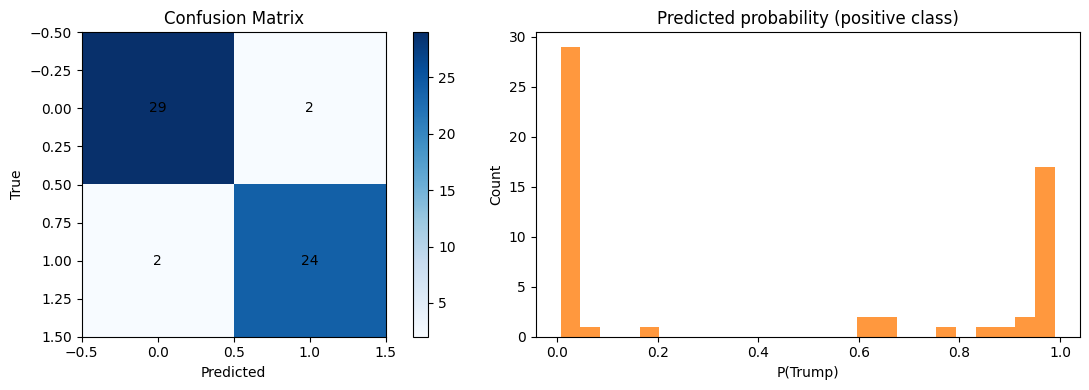

In [10]:
# Plots: confusion matrix and probability histogram
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# confusion matrix heatmap (simple)
cm_plot = cm
im = axes[0].imshow(cm_plot, cmap='Blues')
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
for (i, j), val in np.ndenumerate(cm_plot):
    axes[0].text(j, i, int(val), ha='center', va='center', color='black')
fig.colorbar(im, ax=axes[0])

# probability histogram for positive class
axes[1].hist(all_probs, bins=25, color='C1', alpha=0.8)
axes[1].set_title('Predicted probability (positive class)')
axes[1].set_xlabel('P(Trump)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()